In [5]:
# IMPORT PACKAGES
import geemap
import ee
from google.colab import auth

Please restart Jupyter kernel after installation if you encounter any errors when importing geemap.


ModuleNotFoundError: No module named 'fcntl'

In [ ]:
# INITIALIZE GEE
ee.Authenticate()
ee.Initialize(project='unit-492608')

In [ ]:
# DATASETS IN GEE
# Datasets listing
datasets = geemap.search_ee_data('')
datasets

for dataset in datasets:
    print(dataset)

# Metadata and bands info
info = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').first().getInfo()
print('\nSentinel-2 Bands:')
for band in info['bands']:
    print(f"Band: {band['id']}")
    print(f"  Data type: {band['data_type']['precision']}")
    print(f"  CRS: {band['crs']}")
    print(f"  Transform: {band['crs_transform']}")
    print()

# Assets listing
assets = ee.data.listAssets({'parent': 'projects/ee-joseflastovicka/assets/'})
assets

{'asset_url': 'https://developers.google.com/earth-engine/datasets/catalog/AAFC_ACI', 'end_date': '2023-01-01', 'endyear': '2023', 'id': 'AAFC/ACI', 'provider': 'Agriculture and Agri-Food Canada', 'start_date': '2009-01-01', 'startyear': '2009', 'tags': 'aafc, agriculture, canada, crop, landcover', 'thumbnail_url': 'https://developers.google.com/earth-engine/datasets/images/AAFC/AAFC_ACI_sample.png', 'title': 'Canada AAFC Annual Crop Inventory', 'type': 'image_collection', 'dates': '2009-01-01 - 2023-01-01', 'uid': 'AAFC_ACI'}
{'asset_url': 'https://developers.google.com/earth-engine/datasets/catalog/ACA_reef_habitat_v2_0', 'end_date': '2021-01-01', 'endyear': '2021', 'id': 'ACA/reef_habitat/v2_0', 'provider': 'Allen Coral Atlas Partnership (ACA)', 'start_date': '2018-01-01', 'startyear': '2018', 'tags': 'coral, ocean, oceans, planet-derived, reef, seagrass, sentinel2-derived', 'thumbnail_url': 'https://developers.google.com/earth-engine/datasets/images/ACA/ACA_reef_habitat_v2_0_sample

{'assets': [{'type': 'FOLDER',
   'name': 'projects/ee-joseflastovicka/assets/amalia',
   'id': 'projects/ee-joseflastovicka/assets/amalia',
   'updateTime': '2024-10-04T09:54:01.898731Z'},
  {'type': 'FOLDER',
   'name': 'projects/ee-joseflastovicka/assets/biodiversity',
   'id': 'projects/ee-joseflastovicka/assets/biodiversity',
   'updateTime': '2025-10-31T10:15:34.347846Z'},
  {'type': 'FOLDER',
   'name': 'projects/ee-joseflastovicka/assets/espon',
   'id': 'projects/ee-joseflastovicka/assets/espon',
   'updateTime': '2024-10-27T10:00:46.267078Z'},
  {'type': 'IMAGE',
   'name': 'projects/ee-joseflastovicka/assets/hello',
   'id': 'projects/ee-joseflastovicka/assets/hello',
   'updateTime': '2025-12-04T16:25:13.825395Z'},
  {'type': 'IMAGE',
   'name': 'projects/ee-joseflastovicka/assets/solar_index',
   'id': 'projects/ee-joseflastovicka/assets/solar_index',
   'updateTime': '2025-12-04T13:31:00.590474Z'},
  {'type': 'IMAGE',
   'name': 'projects/ee-joseflastovicka/assets/solar_i

In [ ]:
# STUDY AREA
# Create study area
study_area = (ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017').filter(ee.Filter.eq('country_na', 'Czechia')))
print(study_area.getInfo())

study_area_alternative = ee.Geometry.Polygon([[[12.09, 48.55],[12.09, 51.06],[18.86, 51.06],[18.86, 48.55]]])

# Create a map and add the fishnet grid
Map = geemap.Map()
Map.centerObject(study_area, 7)
Map.addLayer(study_area, {'color': 'red'}, 'Study area')
Map.addLayer(study_area_alternative, {'color': 'blue'}, 'Study area alternative')
Map

{'type': 'FeatureCollection', 'columns': {'abbreviati': 'String', 'country_co': 'String', 'country_na': 'String', 'system:index': 'String', 'wld_rgn': 'String'}, 'version': 1566850254549599, 'id': 'USDOS/LSIB_SIMPLE/2017', 'properties': {'date_range': [1490832000000, 1490832000000], 'period': 0, 'thumb': 'https://mw1.google.com/ges/dd/images/LSIB_thumb.png', 'description': '<p>The United States Office of the Geographer provides\nthe Large Scale International Boundary (LSIB) dataset. The detailed\nversion (2013) is derived from two other datasets: a LSIB line\nvector file and the World Vector Shorelines (WVS) from the National\nGeospatial-Intelligence Agency (NGA). The interior boundaries\nreflect U.S. government policies on boundaries, boundary disputes,\nand sovereignty. The exterior boundaries are derived from the\nWVS; however, the WVS coastline data is outdated and generally\nshifted from between several hundred meters to over a kilometer.\nEach feature is the polygonal area enclos

Map(center=[49.7436252121114, 15.338716833941653], controls=(WidgetControl(options=['position', 'transparent_b…

In [ ]:
# DATA PROCESSING
# Function for cloud masking with SCL and NDVI
def mask_s2_clouds(image):
    scl = image.select('SCL')
    # Povolit jen pixely, které nejsou oblačností nebo stínem
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))
    return image.updateMask(mask)

def ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

# Upload data for Sentinel-2
sentinel2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2025-06-01', '2025-10-01')
    .filter(ee.Filter.calendarRange(4, 10, 'month'))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .map(mask_s2_clouds)
    .map(ndvi)
    .median()
    .clip(study_area))

# Upload SRTM
srtm = (ee.Image('USGS/SRTMGL1_003')).clip(study_area)

# Prepare slope and aspect
srtm_slope = ee.Terrain.slope(srtm)
srtm_aspect = ee.Terrain.aspect(srtm)

# Upload data for summer precipitation
era5_summer_precipitation = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
    .filterDate('2014-01-01', '2025-01-01')
    .filter(ee.Filter.calendarRange(4, 10, 'month'))
    .select('total_precipitation_sum')
    .sum()
    .divide(11) # per year
    .multiply(1000) # per mm
    .clip(study_area)
    .rename('summer_precipitation'))

# Upload data for winter temperature
era5_winter_temperature = (ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR')
    .filterDate('2014-01-01', '2025-01-01')
    .filter(ee.Filter.calendarRange(11, 12, 'month')
            .Or(ee.Filter.calendarRange(1, 3, 'month')))
    .select('temperature_2m')
    .map(lambda image: image.subtract(273.15).copyProperties(image, image.propertyNames()))
    .median()
    .clip(study_area)
    .rename('winter_temperature'))

# Upload data for land cover information
esawc_vegetation = (ee.ImageCollection('ESA/WorldCover/v200')
    .mode()
    .clip(study_area)
    .eq(30)
    .unmask(0)
    .clip(study_area)
    .rename('vegetation'))

# Create a map and add the fishnet grid
Map = geemap.Map()
Map.centerObject(study_area, 7)

# Add Google Maps XYZ tiles
google_maps_xyz = {
    'Google Satellite': 'http://mt0.google.com/vt/lyrs=s&hl=en&x={x}&y={y}&z={z}'
}

Map.add_tile_layer(
    url=google_maps_xyz['Google Satellite'],
    name='Google Satellite',
    attribution='Google',
    opacity=1.0
)

Map.addLayer(sentinel2, {'min': 100,'max': 2300,'bands': ['B4', 'B3', 'B2']}, 'Sentinel-2 True color')
Map.addLayer(sentinel2, {'min': 100,'max': 2300,'bands': ['B5', 'B4', 'B3']}, 'Sentinel-2 False color')
Map.addLayer(sentinel2.select('NDVI'), {'min': -0.1,'max': 0.9,'palette': ['blue', 'yellow', 'green']}, 'Sentinel-2 NDVI')
Map.addLayer(era5_summer_precipitation, {'min': 240,'max': 520,'palette': ['red', 'blue']}, 'Summer precipitation')
Map.addLayer(era5_winter_temperature, {'min': -17,'max': -11,'palette': ['blue', 'red']}, 'Winter temperature')
Map.addLayer(srtm, {'min': 550,'max': 1300,'palette': ['green', 'yellow', 'brown', 'white']}, 'Elevation')
Map.addLayer(srtm_slope, {'min': 0,'max': 1.8,'palette': ['green', 'yellow', 'brown', 'white']}, 'Slope')
Map.addLayer(srtm_aspect, {'min': 0,'max': 359,'palette': ['green', 'yellow', 'brown', 'white']}, 'Aspect')
Map.addLayer(esawc_vegetation, {'min': 0,'max': 1,'palette': ['red', 'green']}, 'Vegetation')

# Display the map
Map

SyntaxError: '(' was never closed (ipython-input-3832175975.py, line 24)

In [ ]:
# TIME SERIES 1
# In-situ locality
point = ee.Geometry.Point([14.5, 50.1])

# Create a map and add the fishnet grid
Map = geemap.Map()
Map.centerObject(study_area, 7)

# Add Google Maps XYZ tiles
google_maps_xyz = {
    'Google Satellite': 'http://mt0.google.com/vt/lyrs=s&hl=en&x={x}&y={y}&z={z}'
}

Map.add_tile_layer(
    url=google_maps_xyz['Google Satellite'],
    name='Google Satellite',
    attribution='Google',
    opacity=1.0
)

Map.addLayer(study_area, {'color': 'blue'}, 'Study area')
Map.addLayer(point, {'color': 'red'}, 'In-situ locality')

# Display the map
Map

Map(center=[49.7436252121114, 15.338716833941653], controls=(WidgetControl(options=['position', 'transparent_b…

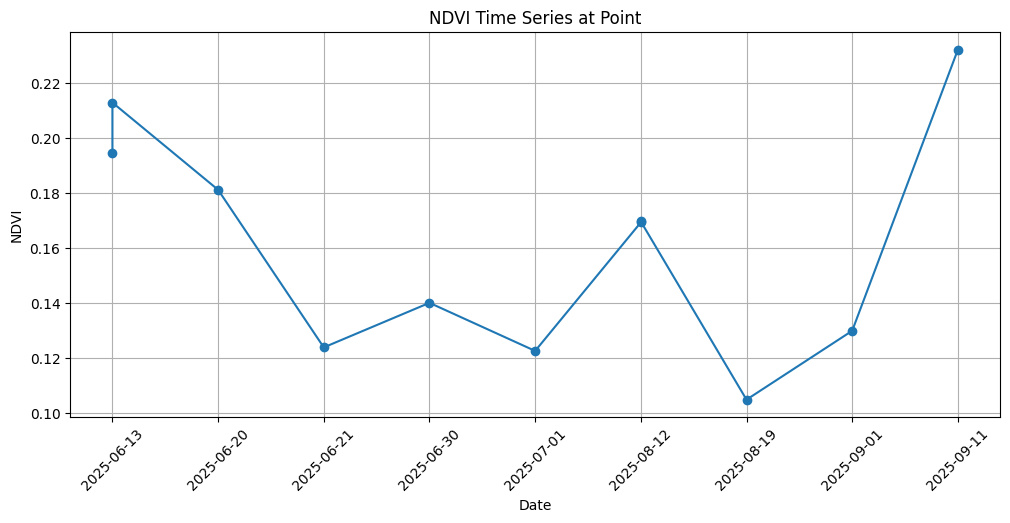

In [ ]:
# TIME SERIES 2
# Upload data for Sentinel-2
sentinel2_ts = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate('2025-06-01', '2025-10-01')
    .filterBounds(study_area)
    .filter(ee.Filter.calendarRange(4, 10, 'month'))
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .map(mask_s2_clouds)
    .map(ndvi))

# Sampling
def extract_ndvi_point(image):
    ndvi_dict = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.first(),
        geometry=point,
        scale=10
    )
    return ee.Feature(None, {
        'date': image.date().format('YYYY-MM-dd'),
        'NDVI': ndvi_dict.get('NDVI')
    })

ndvi_fc = sentinel2_ts.map(extract_ndvi_point)

# Filter No Data
fc_dict = ndvi_fc.getInfo()
features = fc_dict['features']
ndvi_data = []
for f in features:
    props = f['properties']
    ndvi_val = props.get('NDVI')
    if ndvi_val is not None:
        ndvi_data.append((props['date'], ndvi_val))

# Lists of dates and values
dates = [d[0] for d in ndvi_data]
ndvi_values = [d[1] for d in ndvi_data]

# Figure with matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(12,5))
plt.plot(dates, ndvi_values, marker='o')
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('NDVI')
plt.title('NDVI Time Series at Point')
plt.grid(True)
plt.savefig('/content/ndvi_time_series.png', dpi=300)
plt.show()

In [ ]:
# DATA EXPORT TO GOOGLE DRIVE
task = ee.batch.Export.image.toDrive(
    image=sentinel2.select('NDVI'),
    description='NDVI',
    folder='gee',
    fileNamePrefix='NDVI',
    region=study_area.geometry(),
    scale=10,
    maxPixels=1e13
)
task.start()

In [ ]:
# PROCESS OF EXPORTS
tasks = ee.batch.Task.list()
tasks

[<Task 2XVBARJFDMYGG2VHXACVNX4Y EXPORT_IMAGE: NDVI (RUNNING)>,
 <Task SXLLIS4EH327VAS4OEB2PQQ3 EXPORT_IMAGE: hello (COMPLETED)>,
 <Task 4YS64MGAI6JKG7JHKHIXVY3G EXPORT_IMAGE: hello (COMPLETED)>,
 <Task IEUJUQ6RRTDWELPAJAFL3ETN EXPORT_IMAGE: hello (FAILED)>,
 <Task FNOIEEVIZHVLWWSJ64JQZ5IA EXPORT_IMAGE: solar_index (COMPLETED)>,
 <Task PDQ4Y4WMYBENQVTMVGZ6BLTP EXPORT_IMAGE: classifications (COMPLETED)>,
 <Task 256QDJOZFI7DSPSZGZ6G7O2T EXPORT_FEATURES: era5_temperature_transposed (COMPLETED)>,
 <Task XMU2RYGEYFVSLRGPW7EEZGRI EXPORT_IMAGE: NDVI (COMPLETED)>,
 <Task UUEUDCFB33HLSEEVYRXO6LI2 EXPORT_IMAGE: solar_index_czechia (COMPLETED)>]